In [1]:
!pip install nltk textblob

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

from textblob import TextBlob
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("blogs.csv")
df.head()
df.info()


Saving blogs.csv to blogs (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [3]:
df.columns = ['Data', 'Labels']


In [8]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [9]:
import shutil
shutil.rmtree('/root/nltk_data', ignore_errors=True)

# Now re-download cleanly
import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
import nltk
nltk.download('stopwords', force=True)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [17]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


In [18]:
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    filtered = [stemmer.stem(word) for word in tokens if word not in stop_words and word.isalpha()]
    return ' '.join(filtered)

df['Cleaned'] = df['Data'].astype(str).apply(clean_text)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Cleaned']).toarray()
y = df['Labels']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.48      0.83      0.61        18
           comp.graphics       0.79      0.83      0.81        18
 comp.os.ms-windows.misc       0.76      0.86      0.81        22
comp.sys.ibm.pc.hardware       0.86      0.76      0.81        25
   comp.sys.mac.hardware       0.78      0.86      0.82        21
          comp.windows.x       0.91      0.84      0.88        25
            misc.forsale       0.92      0.61      0.73        18
               rec.autos       0.94      0.94      0.94        18
         rec.motorcycles       0.83      0.94      0.88        16
      rec.sport.baseball       0.86      1.00      0.92        18
        rec.sport.hockey       0.94      1.00      0.97        15
               sci.crypt       0.82      0.95      0.88        19
         sci.electronics       0.63      0.75      0.69        16
                 sci.med       0.88      0.88      0

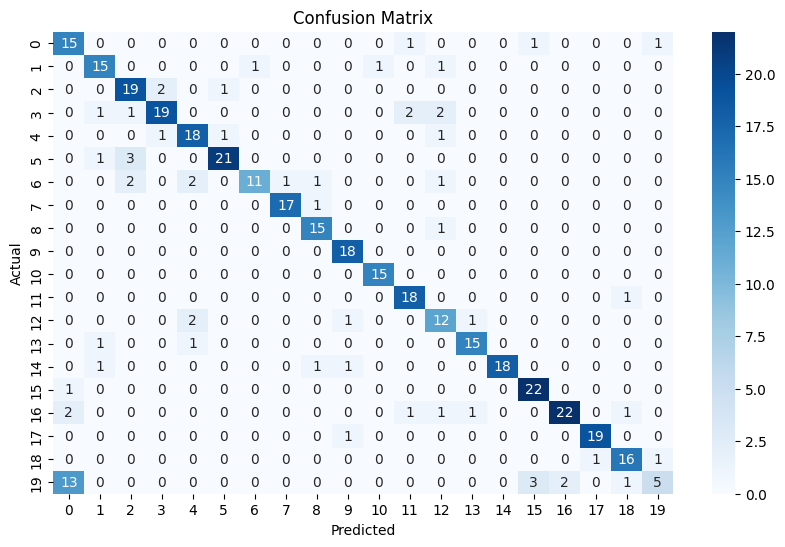

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Print report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [23]:
from textblob import TextBlob

def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Data'].astype(str).apply(get_sentiment)
df[['Data', 'Sentiment']].head()


,Data,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Neutral
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,Neutral
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Neutral
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Neutral
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,Positive


/tmp/ipython-input-24-1975111260.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='pastel')


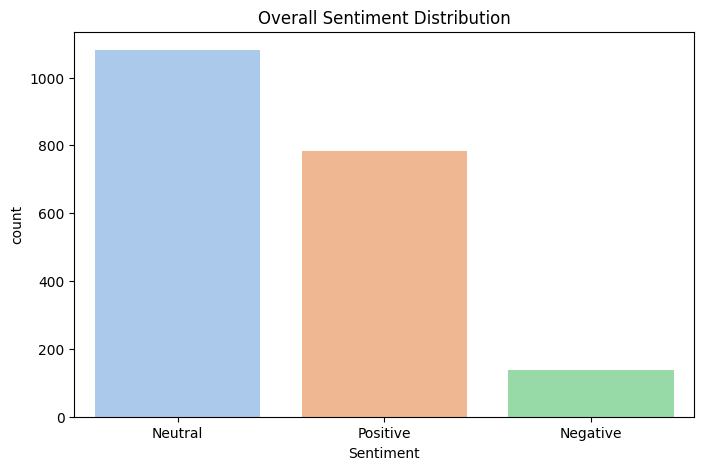

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment', palette='pastel')
plt.title("Overall Sentiment Distribution")
plt.show()


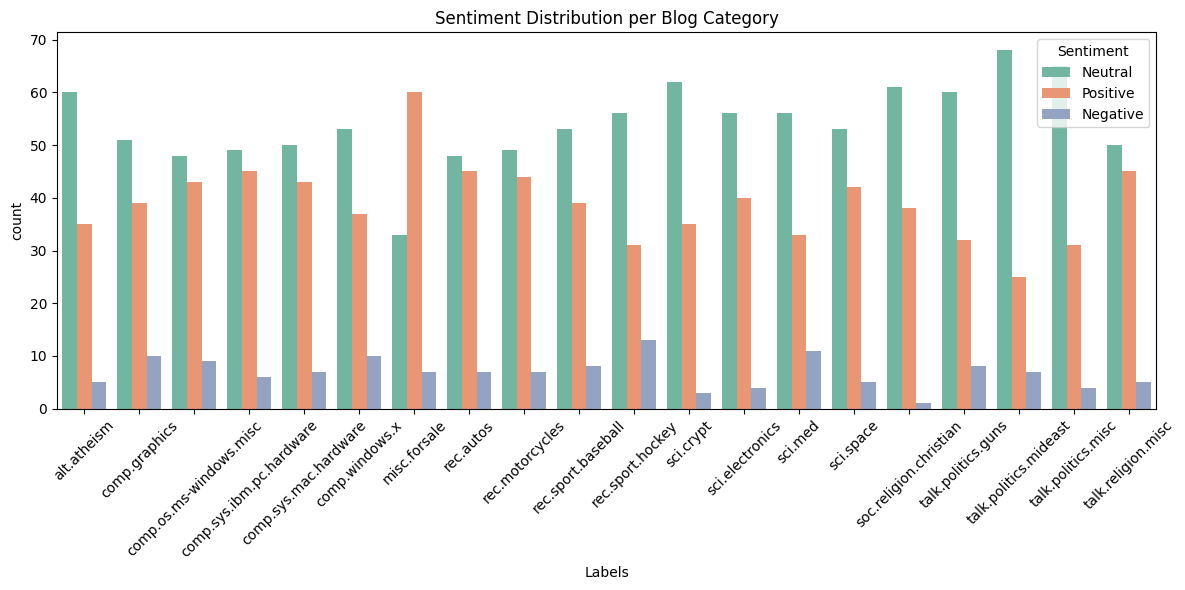

In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Labels', hue='Sentiment', palette='Set2')
plt.title("Sentiment Distribution per Blog Category")
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()
